In [206]:
import math
import scipy.interpolate as spi
from mpl_toolkits.mplot3d import Axes3D
import desc.io
import numpy as np
from scipy import integrate
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.profiles import PowerSeriesProfile
from desc.profiles import MTanhProfile
from desc.profiles import SplineProfile
from desc.plotting import plot_1d, plot_section, plot_surfaces
from desc.grid import LinearGrid
from desc.grid import Grid
from scipy.io import loadmat
from desc.grid import QuadratureGrid
import desc.compute._profiles
import matplotlib.pyplot as plt
from desc.optimize import Optimizer
from scipy.io import savemat
from desc.compute import compute as compute_fun
from desc.objectives import (
    get_fixed_boundary_constraints,
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    ForceBalance,
)

### compute2D脚本用于计算二维平衡。
##### 以下四个设置共同决定唯一平衡：1.安全因子，2.压强剖面，3.最外层磁面形状，4.最外层环向磁通大小。
##### 建议采用control+shift组合键运行**需要的代码块**。
##### **请在操作每一步前，详细查看每一步的说明**。
##### **请在操作每一步前，详细查看每一步的说明**。
##### **请在操作每一步前，详细查看每一步的说明**。

### 第一步，设置q和p的剖面，请选择以下**两种方式之一**。
##### 1.给定q和p关于r/a(0到1)的解析形式，请在1.1代码块的前4行给定系数和次数，然后运行1.1代码块。
##### 其中Qorders与Qparams代表q的次数以及相应系数，Porders与Pparams代表p的相应设置。
##### 
##### 2.给定q和p关于r/a(0到1)的离散数据，请在1.2代码块给定文件，然后运行1.2代码块。
##### 示例读取了matlab文件，请保证文件中Rho，Safety，Pressure的维度为(1,N)且N>=1。
##### 
##### 运行1.3代码块可以查看设置好的q和p。

In [130]:
################## 1.1代码块 ##################
################## 1.1代码块 ##################

Qorders = [0,2,3];
Qparams = [2.71,0.76,1.71];
Porders = [0,2];
Pparams = [6408,-3800];

Rho = np.linspace(0,1,512)
index = np.zeros((Rho.size,3))
index[:,0] = Rho

Safety = PowerSeriesProfile(params=Qparams, modes=Qorders)
Pressure = PowerSeriesProfile(params=Pparams, modes=Porders)

Safety = np.array(Safety.compute(Grid(index)));
Pressure = np.array(Pressure.compute(Grid(index)));

In [131]:
################## 1.2代码块 ##################
################## 1.2代码块 ##################

Rho = loadmat(r"D:\RQP.mat")['Rho'][0]
Safety = loadmat(r"D:\RQP.mat")['Safety'][0]
Pressure = loadmat(r"D:\RQP.mat")['Pressure'][0]

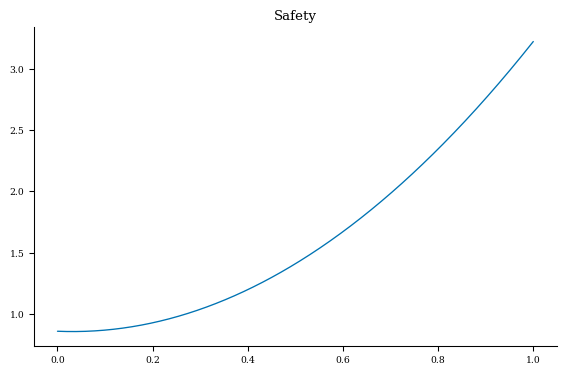

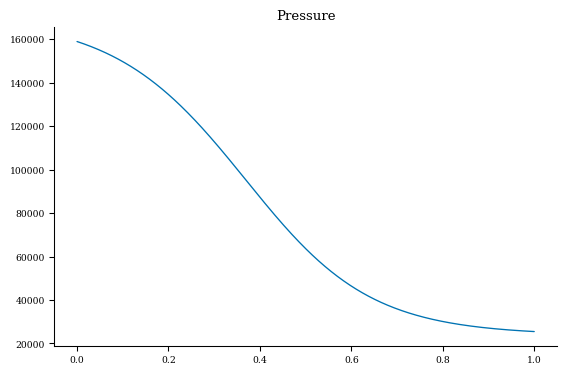

In [132]:
################## 1.3代码块 ##################
################## 1.3代码块 ##################

plt.figure()
plt.plot(Rho,Safety)
plt.title("Safety");

plt.figure()
plt.plot(Rho,Pressure)
plt.title("Pressure");

### 第二步，拟合q和p的剖面。
##### 请在2.1代码块的前2行给定拟合的最高次数，然后运行2.1代码块。
##### 其中iotaMaxOrder与pressureMaxOrder分别代表拟合旋转变换和压强的多项式最高次数。
##### 拟合后会输出四张图片：1.原压强与拟合压强，2.压强相对误差，3.原安全因子与拟合安全因子，4.安全因子相对误差。
##### 其中原数据为蓝色，拟合数据为红色。

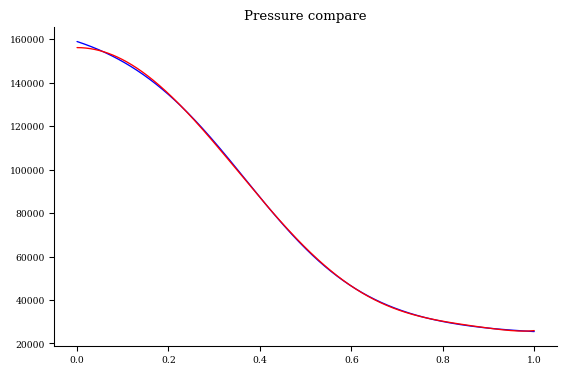

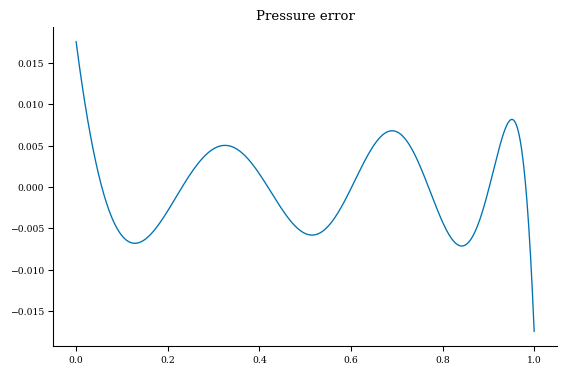

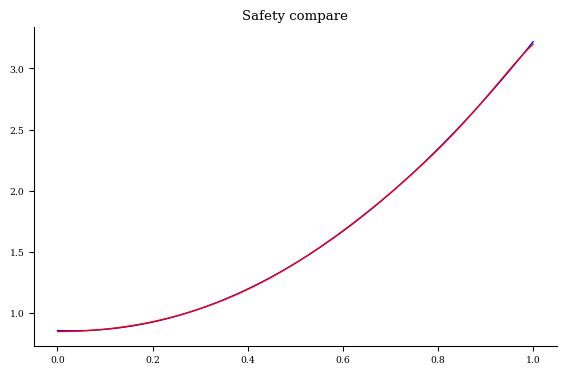

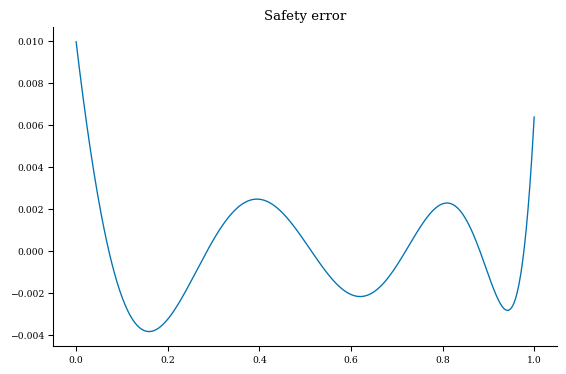

In [184]:
################## 2.1代码块 ##################
################## 2.1代码块 ##################

iotaMaxOrder = 10;
pressureMaxOrder = 10;

iota = PowerSeriesProfile().from_values(Rho, 1./Safety, iotaMaxOrder, sym=True)
pressure = PowerSeriesProfile().from_values(Rho, Pressure, pressureMaxOrder, sym=True)

index = np.zeros((Rho.size,3))
index[:,0] = Rho

plt.figure()
plt.plot(Rho,Pressure,color='blue')
plt.plot(Rho,np.array(pressure.compute(Grid(index))),color='red')
plt.title("Pressure compare");

plt.figure()
plt.plot(Rho,(Pressure-np.array(pressure.compute(Grid(index))))/Pressure)
plt.title("Pressure error");

plt.figure()
plt.plot(Rho,Safety,color='blue')
plt.plot(Rho,1./np.array(iota.compute(Grid(index))),color='red')
plt.title("Safety compare");

plt.figure()
plt.plot(Rho,(Safety-1./np.array(iota.compute(Grid(index))))/Safety)
plt.title("Safety error");

### 第三步，拟合最外层磁面形状。
##### 请在3.1代码块的前4行给定大半径，小半径，拉长比，三角形变，然后运行3.1代码块。
##### 最外层磁面被设置为$R=R_0+a\cos[\theta+\sin(\theta)*\arcsin(delta)],\quad Z=ka\sin(\theta)$。
##### 运行后会输出最外层磁面形状，蓝色为原始数据，红色为拟合数据。

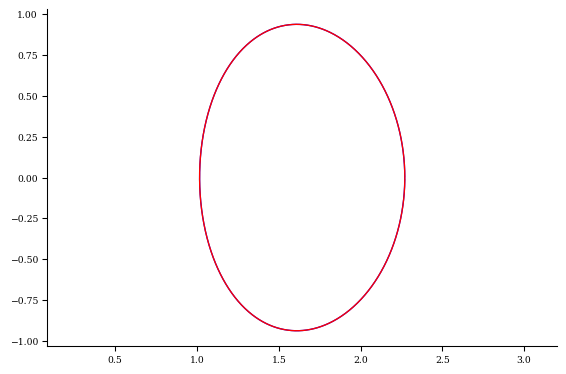

In [198]:
################## 3.1代码块 ##################
################## 3.1代码块 ##################

R0 = 1.643450000000000;
a = 0.627452000000000;
k = 1.495570000000000;
delta = 0.052816500000000;

theta = np.arange(0,2*np.pi,2*np.pi/1024);
Router = R0+a*np.cos(theta+np.sin(theta)*np.arcsin(delta));
Zouter = k*a*np.sin(theta);

n = len(Router)
Rfft = np.abs(np.fft.fft(Router))/n
Rfft[1:] *= 2 
Zfft = np.abs(np.fft.fft(Zouter))/n
Zfft[1:] *= 2 

surface = FourierRZToroidalSurface(
    R_lmn=[Rfft[0],Rfft[1],Rfft[2],Rfft[3]],
    modes_R=[[0, 0], [1, 0], [2, 0], [3, 0]],
    Z_lmn=[-Zfft[1]],
    modes_Z=[[-1, 0]],
)

Router2 = Router.copy();
Router2[:] = 0;
for m in np.arange(0,3,1):
    Router2 = Router2 + Rfft[m]*np.cos(m*theta);

plt.figure();
plt.plot(Router2,Zouter,color='blue');
plt.plot(Router,Zouter,color='red');
plt.axis('equal');

### 第四步，猜测最外层环向磁通。
##### 请在4.1代码块的第一行给定设想的磁轴处磁场大小。

In [197]:
################## 4.1代码块 ##################
################## 4.1代码块 ##################

B00 = 10;
Psi = B00*np.pi*k*a*a;

### 第五步，开始求解平衡。
##### 求解平衡的精度以及快慢取决于平衡参数。
##### **请详细阅读完此步说明，再进行操作，以便快速得到高精度平衡。**
##### **请详细阅读完此步说明，再进行操作，以便快速得到高精度平衡。**
##### **请详细阅读完此步说明，再进行操作，以便快速得到高精度平衡。**
#####
##### DESC的解由傅里叶泽尼柯基展开，二维解的精度由径向模数L，极向模数M，以及相应的系数唯一决定。
##### L_grid以及M_grid则决定每一步在多少径向以及极向网格上优化force error。
#####
##### 以下是通常的求解步骤：
##### 1.在5.1代码块的前2行，设置initialM(初始极向模数)，以及maxMgrid(在多少极向网格上进行优化)，
##### 我们推荐initialM = 16，maxMgrid = 72，然后运行5.1代码块。**注意：5.1代码块在整个过程仅运行1次。**
##### 
##### 2.在5.2代码块的第1行，设置迭代次数，然后运行5.2代码块进行此次迭代。请仔细查看5.2代码块下方的输出，
##### 在输出窗口内滑动鼠标至最下方可以查看normalized Maximum absolute Force error，
##### 我们推荐其低于$10^{-7}$，此时截面上的误差大致都为深蓝色。
##### 你也可以接受直接使用更低的精度。**注意：5.2代码块在整个过程通常需要运行多次。**
#####
##### 3.此次迭代完成后：
##### &emsp;&emsp;请运行5.3代码块查看磁轴处磁场大小，并进入以下求解分支。
##### &emsp;&emsp;**如果磁场大小满足需求**:
##### &emsp;&emsp;&emsp;&emsp;**如果精度满足需求**:请直接进入第6步保存平衡文件。
##### &emsp;&emsp;&emsp;&emsp;**如果精度不满足需求**:进入继续求解平衡。
##### &emsp;&emsp;**如果磁场大小不满足需求**:请运行5.4代码块，进入继续求解平衡。
#####
##### 4.继续求解平衡，以下有**两种方式**可以提高平衡精度：
##### &#9312;再次进入步骤2，即设置迭代次数并运行5.2代码块。
##### &#9313;在5.5代码块的第1行，设置新的极向模数M，newM应当满足initialM<newM<maxMgrid，可以每次加2，
##### 运行5.5代码块。然后再次进入步骤2，即设置迭代次数并运行5.2代码块。
##### 继续求解平衡的过程中，**我们推荐：若在当前设置下，增加迭代次数，误差能够很快减小，则不断使用&#9312;，否则使用&#9313;**。
#####
##### 你的整个平衡求解步骤应当属于以下的**两种情况中一种**：
##### &#9312; 一次求解即满足需求：1->2->3
##### &#9313; 多次求解才满足需求：1->2->3&emsp;->4->2->3&emsp;->4->2->3&emsp;->4->2->3&emsp;......

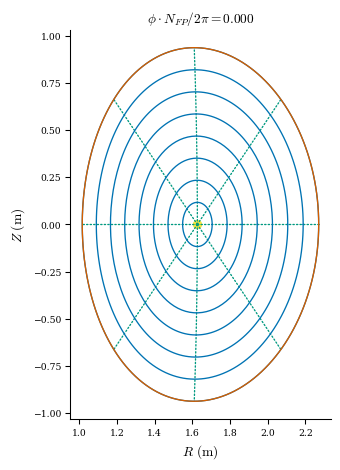

In [200]:
################## 5.1代码块 ##################
################## 5.1代码块 ##################

initialM = 16;
maxMgrid = 72;

eq = Equilibrium(
    surface=surface, 
    pressure=pressure,
    iota=iota,
    Psi=Psi,
    NFP=1,
    M=initialM,
    N=0, 
    M_grid=maxMgrid,
    N_grid=0,  
    sym=True,  
    spectral_indexing="fringe",
)
plot_surfaces(eq);

In [10]:
################## 5.2代码块 ##################
################## 5.2代码块 ##################

maxIter = 500;

optimizer = Optimizer("lsq-exact")

constraints = (
    FixBoundaryR(eq), 
    FixBoundaryZ(eq),  
    FixPressure(eq),  
    FixIota(eq),  
    FixPsi(eq),  
)

objectives = ForceBalance(eq)
obj = ObjectiveFunction(objectives=objectives)

eq.solve(
    verbose=3,
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    maxiter=maxIter,
    constraints=constraints,
    optimizer=optimizer,
    objective=obj,
);

plot_surfaces(eq,10,36)
plot_section(eq, "|F|", norm_F=True, log=True);

Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 114 ms
Timer: Objective build = 133 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed Psi
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 84.8 ms
Timer: Linear constraint projection build = 73.2 ms
Number of parameters: 392
Number of objectives: 2484
Timer: Initializing the optimization = 299 ms

Starting optimization
Using method: lsq-exact
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1          1.298e-01                                    1.191e+02   
       1              5          1.157e-01      1.405e-02      3.808e-01      2.603e+03   
       2              6  

In [97]:
################## 5.3代码块 ##################
################## 5.3代码块 ##################

B0 = eq.compute('|B|',Grid(np.array([0,0,0])))['|B|']
print(B0)

64
72
FourierZernikeBasis at 0x2377d930ed0 (L=32, M=16, N=0, NFP=1, sym=sin, spectral_indexing=fringe)
0.6398948


In [ ]:
################## 5.4代码块 ##################
################## 5.4代码块 ##################

eq.Psi = (B00/B0*eq.Psi)

In [204]:
################## 5.5代码块 ##################
################## 5.5代码块 ##################

newM = 18;
newL = 2*newM;

eq.change_resolution(newL,newM,0,2*newL,maxMgrid,0)

In [205]:
################## 5.6代码块 ##################
################## 5.6代码块 ##################

print(eq.L_grid)
print(eq.M_grid)
print(eq.L_basis)
print(eq.Psi)

176
72
FourierZernikeBasis at 0x1da27f84b90 (L=88, M=44, N=0, NFP=1, sym=sin, spectral_indexing=fringe)
18.497695820277567


In [ ]:
################## 5.7代码块 ##################
################## 5.7代码块 ##################

u0 = 4*np.pi*1.0e-7
B0 = eq.compute('|B|',Grid(np.array([0,0,0])))['|B|']
R0 = eq.compute('R',Grid(np.array([0,0,0])))['R']
p0 = eq.compute('p',Grid(np.array([0,0,0])))['p']

print(B0)
print(R0)
print(p0/(B0*B0/2/u0))

### 第六步，保存平衡文件。
##### 运行6.1代码块，可用任意文件名保存在任意位置，**不要修改后缀名hdf5**。
##### 保存文件前也可以运行5.7代码块查看磁轴磁场大小，磁轴大半径，磁轴比压

In [102]:
################## 6.1代码块 ##################
################## 6.1代码块 ##################

eq.save(r'D:\test.hdf5')